In [ ]:
import torch
import sys
from models.forecasting.diffusion import DDPM
from models.unet.unet import UNet
sys.path.append('../..')
import yaml
from models.model_utils.noise_scheduler import CosineScheduler
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from datasets.diffusion_dataset import DiffusionDataset
from utils.visualisation_utils import tensor_to_gif
import os

# Load in model configs as defined in training_configs

In [2]:
diffusion_training_cfg_path = '../../configs/training_configs/diffusion_training.yaml'
# Add other diffusion forecasting models here

with open(diffusion_training_cfg_path, "r") as file:
    diffusion_cfg = yaml.safe_load(file)

# Load in testing data

In [3]:
test_data_path = '../../data/test_data/heat_equation.pt'
test_data = torch.load(test_data_path, mmap=True)

# Load in the models

## Standard Diffusion Model

In [4]:
# --- Model ---
unet = UNet(
    in_channels=diffusion_cfg['in_channels'],
    out_channels=diffusion_cfg['out_channels'],
    kernel_size=diffusion_cfg['kernel_size'],
    final_filters=diffusion_cfg['final_filters'],
    encoder_dropout=diffusion_cfg['encoder_dropout'],
    input_size=diffusion_cfg['input_size'],
)

noise_schedule = CosineScheduler(T=diffusion_cfg['num_timesteps'], s=diffusion_cfg['cosine_shift']).schedule()

diffusion_model = DDPM(
    denoising_model=unet,
    noise_schedule=noise_schedule,
    optimiser=diffusion_cfg['optimiser'],
    learning_rate=diffusion_cfg['learning_rate']
)

model_path = '../../checkpoints/diffusion_heat/ddpm-epoch=0019-val_loss=0.0000.ckpt'
diffusion_model.load_state_dict(torch.load(model_path)['state_dict'])

<All keys matched successfully>

# Inference and forecasting

## Testing data samples

In [5]:
test_indices = [0, 21, 16]

T = 50

test_1, a_1 = test_data['X'][test_indices[0]][:T,:,:], test_data['a'][test_indices[0]]
test_2, a_2 = test_data['X'][test_indices[1]][:T,:,:], test_data['a'][test_indices[1]]
test_3, a_3 = test_data['X'][test_indices[2]][:T,:,:], test_data['a'][test_indices[2]]

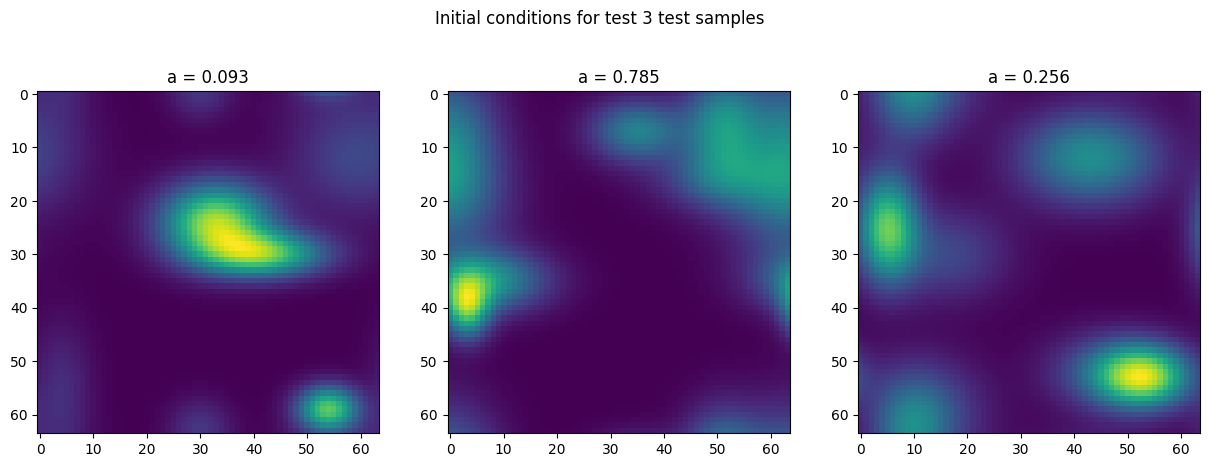

In [6]:
fig, ax = plt.subplots(1, 3, figsize = (15, 5))


fig.suptitle('Initial conditions for test 3 test samples', y = 1)
ax[0].set_title(f'a = {a_1.float():.3f}')
ax[0].imshow(test_1[0].numpy())

ax[1].set_title(f'a = {a_2.float():.3f}')
ax[1].imshow(test_2[0].numpy())

ax[2].set_title(f'a = {a_3.float():.3f}')
ax[2].imshow(test_3[0].numpy())
plt.show()


## Forecasting

In [7]:
num_time_steps = T
all_test_forecasts = []
device = torch.device("mps")
diffusion_model.to(device)
diffusion_model.eval()
for sample_idx in test_indices:
    init_cond, a = test_data['X'][sample_idx][0], test_data['a'][sample_idx]
    X = torch.stack([init_cond] + [torch.full_like(init_cond, a)], dim=0)
    multi_step_output = []
    for t in range(num_time_steps):
        with torch.no_grad():
            output = diffusion_model(X.to(device).unsqueeze(0))
            multi_step_output.append(output.cpu())
            X[0] = output.squeeze().cpu()

    all_test_forecasts.append(multi_step_output)

In [8]:
error_steps = []

for idx, forecast in enumerate(all_test_forecasts):
    test_idx = test_indices[idx]
    error = torch.abs(test_data['X'][test_idx][:T,:,:] - torch.concat(forecast).cpu().squeeze())
    error_steps.append(error)

# Error Visualisation

In [9]:
test_1.shape

torch.Size([50, 64, 64])

In [10]:
# Format data — all tensors → [3, T, 64, 64]
test_gif_formatted     = torch.stack([test_1, test_2, test_3])
forecast_gif_formatted = torch.stack([torch.cat(x).squeeze(1) for x in all_test_forecasts])
error_gif_formatted    = torch.stack(error_steps)
frames_grid            = torch.stack([test_gif_formatted, forecast_gif_formatted, error_gif_formatted])
# frames_grid: [3, 3, T, 64, 64]

In [11]:
forecast_gif_formatted.shape

torch.Size([3, 50, 64, 64])

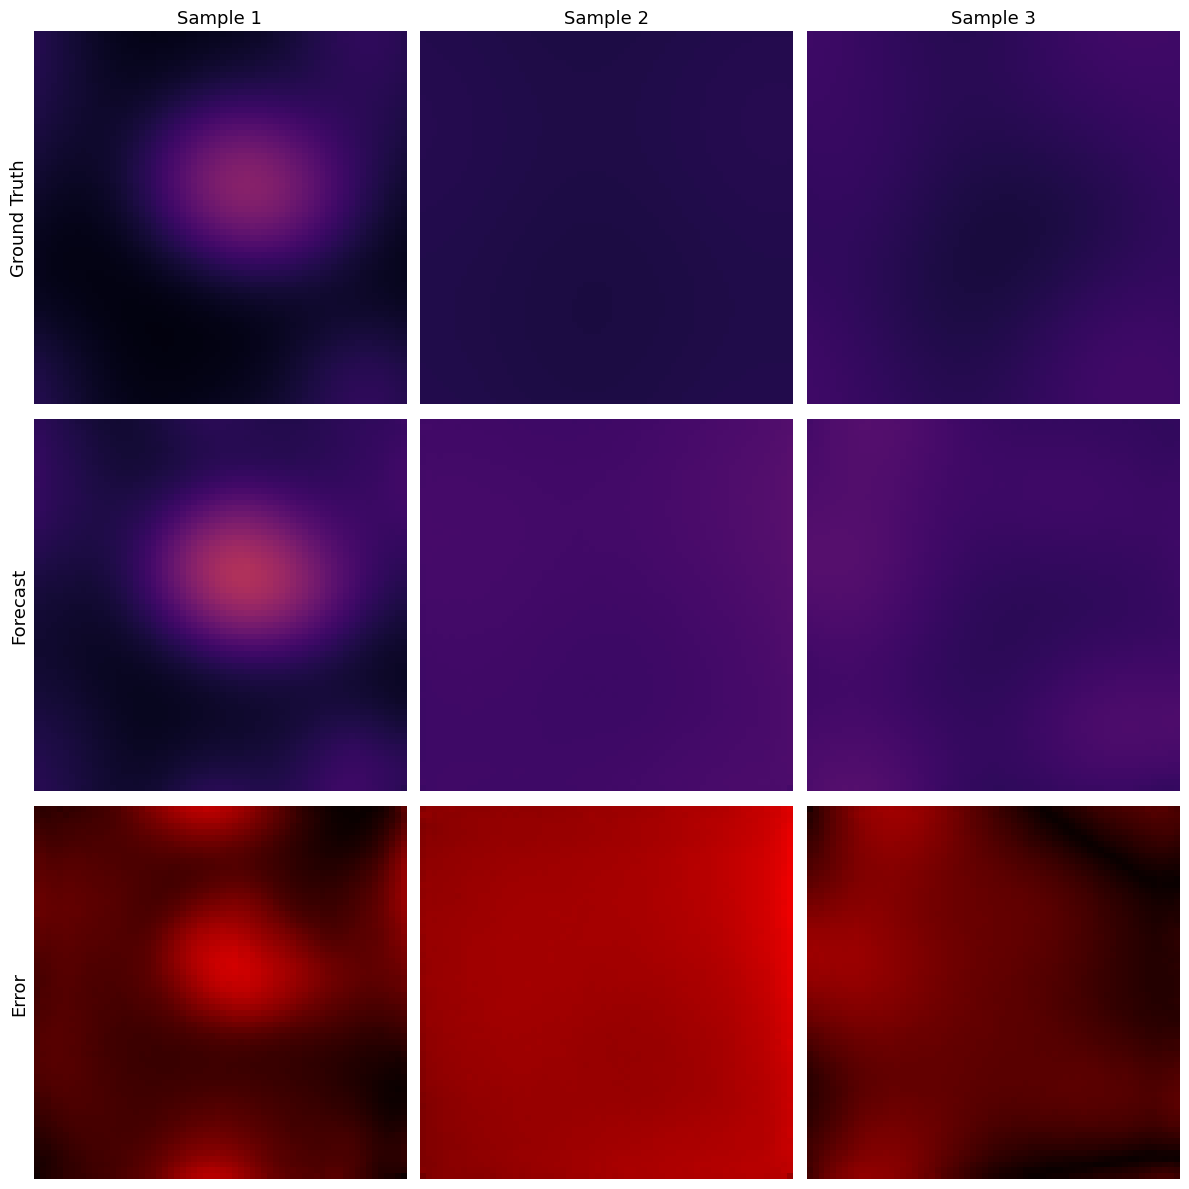

In [13]:
import matplotlib.pyplot as plt
import matplotlib.animation as animation

fig, axes = plt.subplots(3, 3, figsize=(12, 12))

row_labels = ['Ground Truth', 'Forecast', 'Error']
cmaps      = ['inferno', 'inferno', 'hot']
vmins      = [frames_grid[i].min().item() for i in range(3)]
vmaxs      = [frames_grid[i].max().item() for i in range(3)]

for j in range(3):
    axes[0, j].set_title(f'Sample {j+1}', fontsize=13)
for i in range(3):
    axes[i, 0].set_ylabel(row_labels[i], fontsize=13)

ims = []
for i in range(3):
    for j in range(3):
        im = axes[i, j].imshow(
            frames_grid[i, j, 0].numpy(), animated=True,
            cmap=cmaps[i], vmin=vmins[i], vmax=vmaxs[i]
        )
        axes[i, j].set_xticks([])
        axes[i, j].set_yticks([])
        for spine in axes[i, j].spines.values():
            spine.set_visible(False)
        ims.append(im)

def update(frame):
    for idx, (i, j) in enumerate([(i, j) for i in range(3) for j in range(3)]):
        ims[idx].set_data(frames_grid[i, j, frame].numpy())
    return ims

num_frames = frames_grid.shape[2]
ani = animation.FuncAnimation(fig, update, frames=num_frames, interval=100, blit=True)

save_path = '../../visualisations/heat_forecast_grid.gif'
os.makedirs(os.path.dirname(save_path), exist_ok=True)
ani.save(save_path, writer="pillow")
plt.tight_layout()
plt.show()